In [ ]:
import gymnasium as gym
import tensorflow as tf
import numpy as np
import cv2
from collections import deque
from datetime import datetime
from pathlib import Path
import keras
from tensorflow.summary import create_file_writer
import os
import matplotlib.pyplot as plt

def pid(error, prev_error):
    Kp, Ki, Kd = 0.02, 0.03, 0.2
    return Kp * error + Ki * (error + prev_error) + Kd * (error - prev_error)

def preprocess_frame(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (36, 25, 25), (70, 255, 255))
    green = np.zeros_like(frame)
    green[mask > 0] = frame[mask > 0]
    gray = cv2.cvtColor(green, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    canny = cv2.Canny(blur, 50, 150)
    cropped = canny[270:272, 200:400]
    return cropped

def find_error(crop, prev_error):
    nz = cv2.findNonZero(crop)
    mid = 100
    if nz is None:
        return prev_error
    if nz[:, 0, 0].max() == nz[:, 0, 0].min():
        return -15 if nz[:, 0, 0].max() >= mid else 15
    return ((nz[:, 0, 0].max() + nz[:, 0, 0].min()) / 2) - mid

def build_model():
    image_input = tf.keras.Input(shape=(5, 200, 1), name="canny_crop")

    # Smaller Conv stack
    x1 = tf.keras.layers.Conv2D(16, (3, 3), padding="same", activation="relu")(image_input)
    x1 = tf.keras.layers.MaxPooling2D()(x1)
    x1 = tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x1)
    x1 = tf.keras.layers.MaxPooling2D()(x1)
    x1 = tf.keras.layers.Flatten()(x1)

    # Simpler error processing
    error_input = tf.keras.Input(shape=(1,), name="error")
    x2 = tf.keras.layers.Dense(8, activation="relu")(error_input)

    # Fuse and output Q-values for 3 gas levels
    concat = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Dense(32, activation="relu")(concat)
    output = tf.keras.layers.Dense(3, activation=None)(x)

    model = tf.keras.models.Model(inputs=[image_input, error_input], outputs=output)
    model.compile(optimizer="adam", loss="mse")
    return model


def preprocess_inputs(crop, error):
    crop = crop.astype(np.float32) / 255.0
    crop = crop.reshape(1, 5, 200, 1)
    return [crop, np.array([[error / 100]], dtype=np.float32)]

def train_step(ep):
    batch_size = min(64, len(replay_buffer) // 10)
    batch = [replay_buffer[np.random.randint(len(replay_buffer))] for _ in range(batch_size)]
    crops, errors, action_idxs = zip(*batch)
    X_img = np.array(crops).reshape(batch_size, 5, 200, 1)
    X_err = np.array(errors).reshape(batch_size, 1)
    action_idxs = np.array(action_idxs, dtype=np.int32)

    q_values = model.predict([X_img, X_err], verbose=0)
    q_values_next = target_model.predict([X_img, X_err], verbose=0)
    targets = q_values.copy()

    for i in range(batch_size):
        action = action_idxs[i]
        targets[i, action] = q_values_next[i, action]

    loss = model.train_on_batch([X_img, X_err], targets)
    losses.append(loss)
    with writer.as_default():
        tf.summary.scalar("Loss/train", loss, step=ep)

2025-04-10 15:58:55.860605: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-10 15:58:55.869310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744315135.877527 2036928 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744315135.880043 2036928 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744315135.886698 2036928 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
model = build_model()
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
writer = create_file_writer(log_dir)

replay_buffer = deque(maxlen=20000)
env = gym.make("CarRacing-v3", render_mode="rgb_array", lap_complete_percent=0.95, domain_randomize=False, continuous=True)
np.random.seed(42)
tf.random.set_seed(42)
env.reset(seed=42)

episodes = 1
rewards = []
best_score = -1000
gas_levels = [0.0, 0.5, 1.0]
losses = []

I0000 00:00:1744315158.817296 2036928 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13553 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
for ep in range(episodes):
    obs, _ = env.reset()
    total_reward = 0
    prev_error = 0
    smoothed_reward = 0

    for step in range(1000):
        frame = env.render()
        crop = preprocess_frame(frame)
        error = find_error(crop, prev_error)

        steering = pid(error, prev_error)
        q_values = model.predict(preprocess_inputs(crop, error), verbose=0)[0]
        action_index = np.argmax(q_values)

        # just gas
        gas = gas_levels[action_index]
        action = np.array([steering, gas, 0], dtype=np.float32)

        # gas and break
        # pick = action_lst[action_index]
        # action = np.array([*pick, 0], dtype=np.float32)

        obs, reward, terminated, truncated, _ = env.step(action)
        smoothed_reward = 0.9 * smoothed_reward + 0.1 * float(reward)
        total_reward += smoothed_reward
        replay_buffer.append((crop, error, action_index))
        prev_error = error

        if len(replay_buffer) > 1000 and step % 4 == 0:
            train_step(ep)
            tau = 0.005
            for var, target_var in zip(model.trainable_variables, target_model.trainable_variables):
                target_var.assign(tau * var + (1 - tau) * target_var)
            with writer.as_default():
                for layer in model.layers:
                    weights = layer.get_weights()
                    if weights:
                        tf.summary.histogram(f"{layer.name}/weights", weights[0], step=ep)

        if terminated or truncated:
            break


    print(f"Episode {ep+1} - Reward: {total_reward:.2f}")
    rewards.append(total_reward)
    with writer.as_default():
        tf.summary.scalar("Reward/Episode", total_reward, step=ep)

    if total_reward > best_score:
        best_score = total_reward
        print(f" - New best score: {best_score:.2f}")
        if best_score > 100:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M")
            Path("models").mkdir(parents=True, exist_ok=True)
            file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
            keras.saving.save_model(model, file_path)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
Path("models").mkdir(parents=True, exist_ok=True)
file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
keras.saving.save_model(model, file_path)

env.close()
writer.close()

I0000 00:00:1744315164.414949 2037199 service.cc:152] XLA service 0x7f20c80039c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744315164.414975 2037199 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9
2025-04-10 15:59:24.428931: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744315164.455430 2037199 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1744315164.913284 2037199 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Episode 1 - Reward: -33.53


 - New best score: -33.53


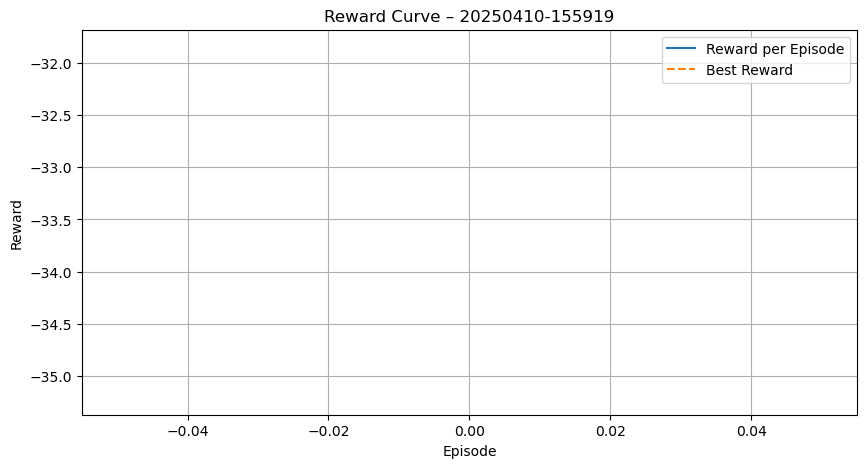

Saved plots to: images/20250410-155919_reward_plot_20250410_1601.png


In [5]:
# ========== Plot and Save Curves ==========
Path("images").mkdir(exist_ok=True)
model_name = Path(log_dir).name
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Reward Plot
plt.figure(figsize=(10, 5))
plt.plot(rewards, label="Reward per Episode")
plt.plot([max(rewards[:i+1]) for i in range(len(rewards))], linestyle='--', label="Best Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title(f"Reward Curve – {model_name}")
plt.grid(True)
plt.legend()
reward_path = f"images/{model_name}_reward_plot_{timestamp}.png"
plt.savefig(reward_path)
plt.show()

# Loss Plot
if losses:
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label="Loss per Train Step")
    plt.xlabel("Train Step")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve – {model_name}")
    plt.grid(True)
    plt.legend()
    loss_path = f"images/{model_name}_loss_plot_{timestamp}.png"
    plt.savefig(loss_path)
    plt.show()

print(f"Saved plots to: {reward_path}")